In [ ]:
pip install python-docx

In [ ]:
import docx

def get_text_from_docx(file_path):
    document = docx.Document(file_path)
    full_text = []
    for para in document.paragraphs:
        full_text.append(para.text)
    return '\n'.join(full_text)

docx_file_path = '/content/ML LAB EXP 5.docx'
text_content = get_text_from_docx(docx_file_path)
print(text_content)

### Installing Required Libraries

In [3]:
# The original text had '!mamba install', which is not directly supported in Colab.
# I will use pip install instead for scikit-learn and pandas.
# If you intend to use mamba, you'll need to install it first, e.g., with `!pip install mamba`.
!pip install scikit-learn pandas seaborn

### Importing Modules

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
from sklearn import datasets

### Machine Learning Workflow

In [5]:
# Importing dataset
iris=datasets.load_iris()
iris_data=iris.data
iris_target=iris.target
print("Iris data:",iris_data[:5])
print("Iris target:",iris_target[:5])
X_train,X_test,y_train,y_test=train_test_split(iris_data,iris_target,test_size=0.3,random_state=42)
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
print("Classification Report:")
print(classification_report(y_test,y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred))

Iris data: [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
Iris target: [0 0 0 0 0]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


### Data Visualization: Iris Dataset

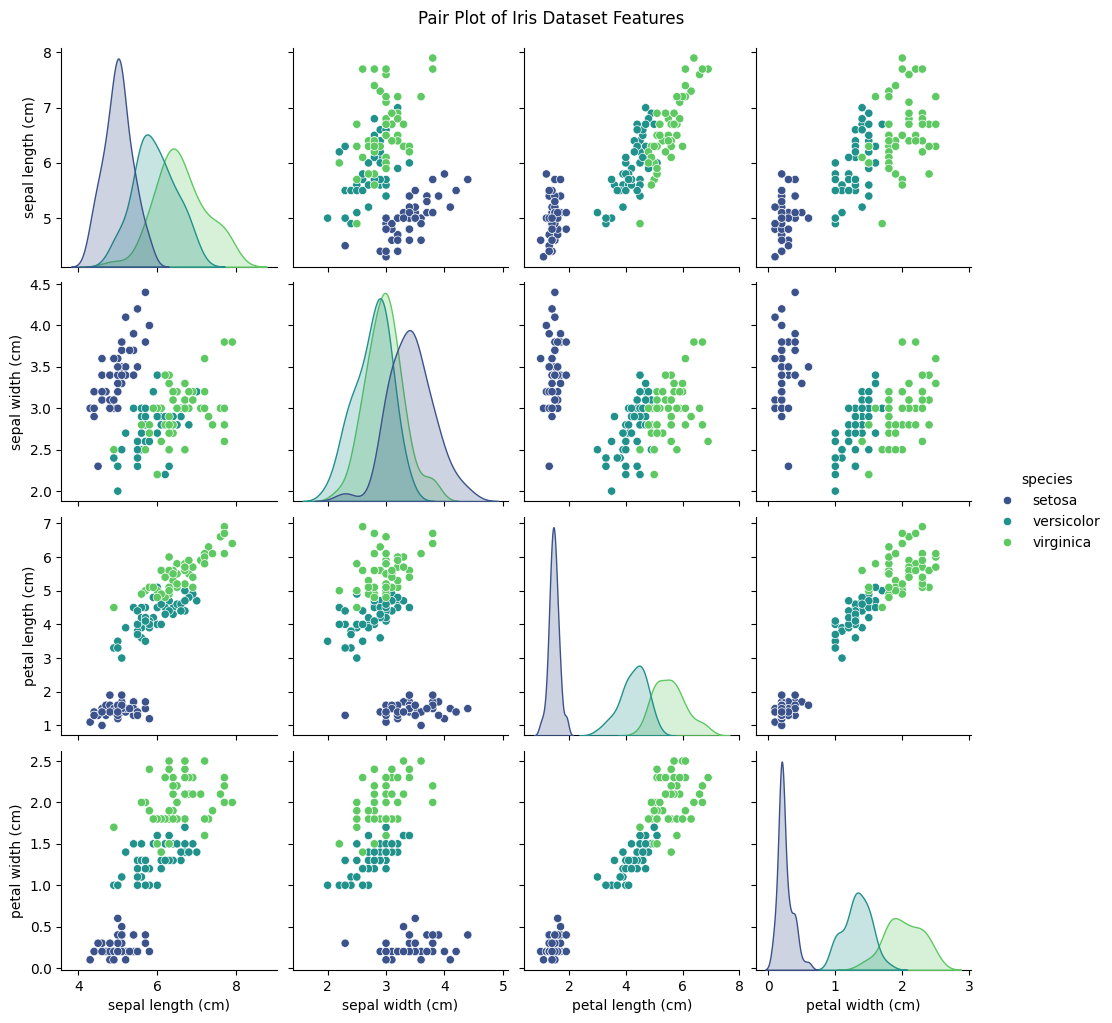

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame for easier plotting with seaborn
iris_df = pd.DataFrame(iris_data, columns=iris.feature_names)
iris_df['species'] = iris.target_names[iris_target]

# Pairplot to visualize relationships between features colored by species
sns.pairplot(iris_df, hue='species', palette='viridis')
plt.suptitle('Pair Plot of Iris Dataset Features', y=1.02) # Add a title above the subplots
plt.show()

### Visualization: Confusion Matrix

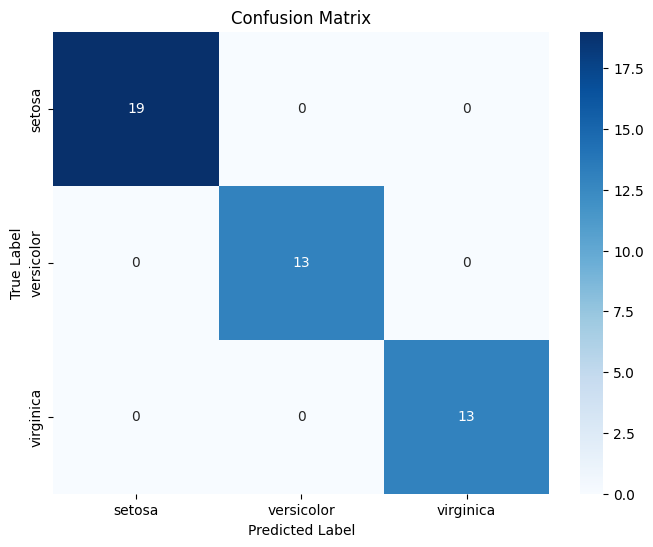

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()